# Feynman calculations with feynsage: first steps

This notebook is for someone who has just met quantum field theory and Feynman diagrams and wants to
compute with them. It shows, one small step at a time, how feynsage does each part of a Feynman calculation.

How it is written:
- every code cell is short and calls feynsage directly, there are no helper functions to understand first
- before each cell you will find what it does and what every argument means
- after each cell you will find what to look at in the output and how we know it is right (mostly a formula
  from Peskin and Schroeder, *An Introduction to Quantum Field Theory*)

**How to run it.** Open it with the SageMath kernel, from the top folder of the feynsage repository or from
`examples/`, and run the cells from top to bottom. The Dirac traces need FORM, which `install.sh` installs.

**Contents**
0. The recipe of every Feynman calculation
1. A tree diagram: $e^+e^- \to \mu^+\mu^-$
2. The first loop: the tadpole $A_0$ and what $1/\epsilon$ means
3. The bubble $B_0$: thresholds and imaginary parts
4. Physics from a loop: the running coupling of $\lambda\varphi^4$
5. Loop momentum in the numerator
6. Triangles and boxes: $C_0$ and $D_0$
7. QED at one loop: the electron's $g - 2$
8. Feynman parameters and the graph polynomials $\mathcal U$, $\mathcal F$
9. Two loops: many integrals, few master integrals
10. Getting help inside feynsage
11. Your own calculation: a checklist and exercises

## 0. The recipe of every Feynman calculation

Whatever the process, a Feynman calculation goes through the same steps.

| Step | What you do | feynsage |
|---|---|---|
| 1 | Draw the diagrams | `diagram`, `graph`, `.plot()` |
| 2 | Write the amplitude with the Feynman rules | on paper, this part is physics |
| 3 | Do the Dirac algebra (traces of gamma matrices) | `dirac_trace`, `spin_sum`, `contract` |
| 4 | Do the loop integrals | `A0`, `B0`, `C0`, `D0`, `loop`, `ibp_reduce` |
| 5 | Remove the $1/\epsilon$ poles (renormalisation) | `uv_part`, `finite_part` |
| 6 | Put in numbers, make plots | `.n()`, `quick_plot` |

Step 2 is yours. feynsage helps with all the others. The first cell loads the package.

In [1]:
import sys, os
# use the feynsage of this repository (not needed once feynsage is installed)
sys.path.insert(0, os.path.abspath('..') if os.path.basename(os.getcwd()) == 'examples' else os.getcwd())
from feynsage import *
from feynsage.plotting import set_theme, quick_plot
set_theme()
%matplotlib inline

## 1. A tree diagram: $e^+e^- \to \mu^+\mu^-$

The electron ($p$) and the positron ($p'$) annihilate into a photon, which makes a muon ($k$) and an
antimuon ($k'$). There is one diagram and no loop. With the masses set to zero the amplitude is
$$\mathcal M = \frac{e^2}{s}\,\big[\bar v(p')\gamma^\mu u(p)\big]\,\big[\bar u(k)\gamma_\mu v(k')\big]$$
We do not measure spins, so we average over the initial spins and sum over the final ones. The spin sums
turn each bracket into a trace of gamma matrices:
$$\frac14\sum_{\rm spins}|\mathcal M|^2 = \frac{e^4}{4s^2}\,
\mathrm{Tr}\big[\not p'\gamma^\mu\not p\,\gamma^\nu\big]\;\mathrm{Tr}\big[\not k\,\gamma_\mu\not k'\gamma_\nu\big]$$

feynsage lets us write this exactly as in the book. First we say which symbols are momenta and which are
Lorentz indices. We write `pp` for $p'$ and `kp` for $k'$ (`latex_name` only says how they are printed).
Then the amplitude is a product of spinors and gamma matrices, in the order of the formula:
- `u(p)`, `v(p)` are the spinors $u(p)$, $v(p)$ and `ubar(p)`, `vbar(p)` are $\bar u(p)$, $\bar v(p)$
- `gamma(mu)` is $\gamma^\mu$. The index `mu` appears twice, so it is summed over

In [2]:
p, pp, k, kp = momenta("p pp k kp", latex_name=["p", "p'", "k", "k'"])
mu = lorentz_indices("mu")
M = vbar(pp) * gamma(mu) * u(p) * ubar(k) * gamma(mu) * v(kp)
show(M)

vbar(pp)*gamma(mu)*u(p)*ubar(k)*gamma(mu)*v(kp)

`spin_sum` sums $|\mathcal M|^2$ over all spins. It puts in $\sum u\bar u = \not p + m$ and $\sum v\bar v = \not p - m$
(here $m = 0$) and lets the program FORM take the two traces. `conjugate(M)` is $\mathcal M^*$.
`rules` gives the scalar products. For massless particles $p\cdot p = 0$ and, with
$s = (p + p')^2$, $t = (p - k)^2$, $u = (p - k')^2$, we have $p\cdot p' = s/2$, $p\cdot k = -t/2$, $p\cdot k' = -u/2$.
From this cell on `u` is the Mandelstam variable, so we built $\mathcal M$ first.

In [3]:
s, t, u = var('s t u')
traces = spin_sum(M * conjugate(M),
                  rules={dot(p, p): 0, dot(pp, pp): 0, dot(k, k): 0, dot(kp, kp): 0,
                         dot(p, pp): s/2, dot(k, kp): s/2,
                         dot(p, k): -t/2, dot(pp, kp): -t/2, dot(p, kp): -u/2, dot(pp, k): -u/2})
traces

8*t^2 + 8*u^2

So $\frac14\sum|\mathcal M|^2 = \frac{e^4}{4s^2}\,8(t^2 + u^2) = 2e^4\,\frac{t^2 + u^2}{s^2}$.

Now go to the centre-of-mass frame. With $\theta$ the angle between the electron and the muon,
$t = -\frac s2(1 - \cos\theta)$ and $u = -\frac s2(1 + \cos\theta)$. For two massless particles in the final state
$\frac{d\sigma}{d\Omega} = \frac{1}{64\pi^2 s}\cdot\frac14\sum|\mathcal M|^2$ and $e^2 = 4\pi\alpha$.

In [4]:
e, alpha, theta = var('e alpha theta')
M2 = e^4 / (4*s^2) * traces
M2 = M2.subs(t=-s/2*(1 - cos(theta)), u=-s/2*(1 + cos(theta)))
dsigma = (M2 / (64*pi^2*s)).subs(e=sqrt(4*pi*alpha)).simplify_full()
dsigma = dsigma.subs(sin(theta)^2 == 1 - cos(theta)^2).factor()     # write it with cos(theta)
sigma = 2*pi*integrate(dsigma*sin(theta), theta, 0, pi)
print("dsigma/dOmega =", dsigma)
print("sigma         =", sigma.simplify_full())

dsigma/dOmega = 1/4*(cos(theta)^2 + 1)*alpha^2/s
sigma         = 4/3*pi*alpha^2/s


**Check.** $\frac{d\sigma}{d\Omega} = \frac{\alpha^2}{4s}(1 + \cos^2\theta)$ and $\sigma = \frac{4\pi\alpha^2}{3s}$. These are
Peskin and Schroeder eqs. (5.12) and (5.13) with the muon mass set to zero ($E_{\rm cm}^2 = s$).
The $1 + \cos^2\theta$ is what the experiments at electron-positron colliders see.

## 2. The first loop: the tadpole $A_0$ and what $1/\epsilon$ means

In $\lambda\varphi^4$ theory the first correction to the mass is a loop that starts and ends at one vertex.
Its integral is $\int d^4\ell\,\frac{1}{\ell^2 - m^2}$. For large $\ell$ the integrand falls only like $1/\ell^2$
while the volume grows like $\ell^3\,d\ell$, so the integral is infinite.

**Dimensional regularisation.** Do the integral in $D = 4 - 2\epsilon$ dimensions. There it is finite and the
infinity comes back as a pole $1/\epsilon$. A scale $\mu$ appears to keep the units right.

feynsage's `A0`, `B0`, `C0`, `D0` use the normalisation of Package-X and LoopTools, the usual one in particle physics:
$$A_0(m) = \mu^{2\epsilon}e^{\epsilon\gamma_E}\int\frac{d^D\ell}{i\pi^{D/2}}\,\frac{1}{\ell^2 - m^2}$$
To go back to the physics measure use $\int\frac{d^4\ell}{(2\pi)^4} = \frac{i}{16\pi^2}\times$(this normalisation).

In [5]:
m = var('m')
A0(m)

m^2*(1/eps + log(mu^2/m^2) + 1)

`eps` is $\epsilon$ and `mu` is $\mu$. Two functions split such a result into its two parts:
`uv_part` gives the coefficient of $1/\epsilon$ (the infinite part) and `finite_part` gives what is left.

In [6]:
print("coefficient of 1/eps:", uv_part(A0(m)))
print("finite part         :", finite_part(A0(m)))

coefficient of 1/eps: m^2
finite part         : m^2*log(mu^2/m^2) + m^2


The pole $m^2/\epsilon$ is removed by a counterterm (renormalisation of the mass). What remains depends on
$\log(\mu^2/m^2)$. Physical answers do not depend on $\mu$ in the end. Section 4 uses exactly this fact.

## 3. The bubble $B_0$: thresholds and imaginary parts

Two propagators, $(\ell, m_1)$ and $(\ell + p, m_2)$, with $s = p^2$. This loop sits in the photon propagator
of QED and in every $2\to2$ scattering of $\lambda\varphi^4$. The call is `B0(s, m1, m2)`.

In [7]:
B0(s, m, m)

1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2

`DiscB` is the function that knows about the threshold $s = (m_1 + m_2)^2$. `disc_expand` writes it with a
square root and a logarithm, if you want to see it:

In [8]:
disc_expand(B0(s, m, m))

sqrt(-4*m^2*s + s^2)*log(1/2*(2*m^2 - s + sqrt(-4*m^2*s + s^2))/m^2)/s + 1/eps + log(mu^2/m^2) + 2

Now numbers, with $m = 1$ and $\mu = 1$ (`finite_part(expr, 1)` sets $\mu = 1$). The threshold is at
$s = 4m^2 = 4$.

In [9]:
for value in [-2, 2, 6, 10]:
    print("s =", value, "   B0 =", finite_part(B0(value, 1, 1), 1).n(digits=10))

s = -2    B0 = -0.2810379890
s = 2    B0 = 0.4292036730
s = 6    B0 = 1.239654004 + 1.813799364*I
s = 10    B0 = 0.4016685192 + 2.433467206*I


Below $s = 4$ the bubble is real. Above it, it has an imaginary part. Above the threshold the two particles
in the loop can be real, and the imaginary part is the probability of making them (the optical theorem).
For the bubble it is $\pi\beta$ with $\beta = \sqrt{1 - 4m^2/s}$, the speed of each particle:

In [10]:
print("Im B0 at s = 6:", finite_part(B0(6, 1, 1), 1).n().imag())
print("pi * beta     :", (pi*sqrt(1 - 4/6)).n())

Im B0 at s = 6: 1.81379936423422
pi * beta     : 1.81379936423422


`quick_plot(expression, (variable, from, to))` draws the real and the imaginary part. Look at the kink at
$s = 4$ where the imaginary part switches on.

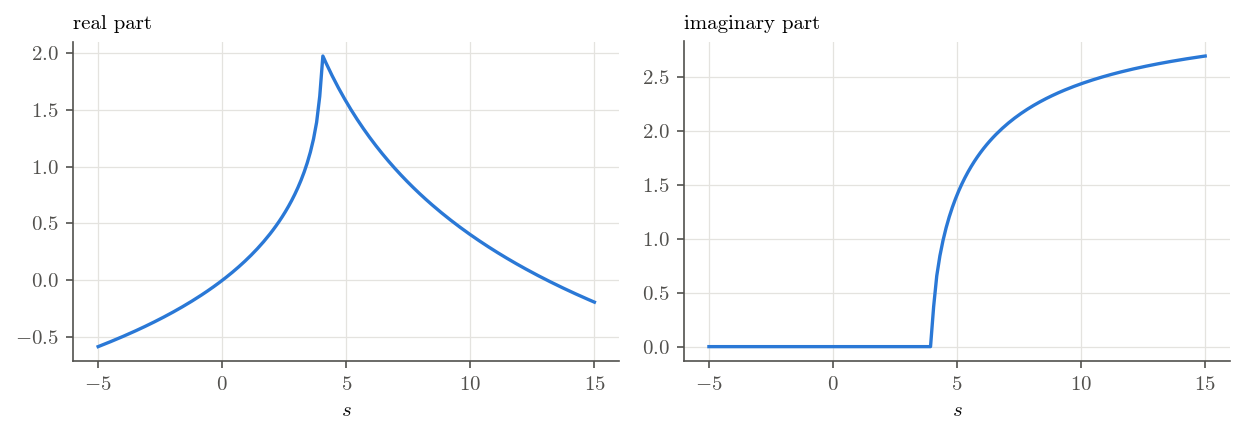

In [11]:
quick_plot(finite_part(B0(s, 1, 1), 1), (s, -5, 15));

## 4. Physics from a loop: the running coupling of $\lambda\varphi^4$

In $\lambda\varphi^4$ theory, $2 \to 2$ scattering at one loop has one bubble in each channel $s$, $t$, $u$.
The Feynman rules give the vertex $-i\lambda$, a symmetry factor $\frac12$ and two propagators. Together with
$\int\frac{d^4\ell}{(2\pi)^4} = \frac{i}{16\pi^2}\times$(our normalisation) this makes
$$\mathcal M = -\lambda + \frac{\lambda^2}{32\pi^2}\big[B_0(s) + B_0(t) + B_0(u)\big]$$
The $1/\epsilon$ poles are removed by a counterterm. What is left depends on $\mu$. A measured amplitude cannot
depend on our choice of $\mu$, so $\lambda$ itself must change with $\mu$, by just the right amount:
$\beta(\lambda) = \mu\,\frac{d\lambda}{d\mu} = \mu\,\frac{\partial}{\partial\mu}\big(\text{loop part}\big)$.

In [12]:
lam = var('lambda_')
M = -lam + lam^2/(32*pi^2) * (B0(s, m, m) + B0(t, m, m) + B0(u, m, m))
beta = (mu * diff(M, mu)).simplify_full()
beta

3/16*lambda_^2/pi^2

**Check.** $\beta(\lambda) = \frac{3\lambda^2}{16\pi^2}$, Peskin and Schroeder eq. (12.46). It is positive, so the
coupling grows at higher energies. The 3 comes from the three channels.

## 5. Loop momentum in the numerator

With fermions and photons the numerator of a loop contains the loop momentum, for example $\ell^\mu$ or
$\ell^\mu\ell^\nu$. `loop` reduces such tensor integrals to $A_0$, $B_0$, $C_0$, $D_0$
(Passarino-Veltman reduction). Its arguments:
- the numerator as a string, `"l^mu"`, `"l^mu l^nu"`, `"l^2"`, `"l.p"` ...
- one list per propagator, `["momentum", "mass"]`
- `kin`: the external scalar products

In [13]:
r = loop("l^mu", ["l", "m"], ["l + p", "m"], kin={"p^2": "s"})
r

p^mu :  -1/2/eps - 1/2*DiscB(s, m, m) - 1/2*log(mu^2/m^2) - 1

The answer is $p^\mu$ times a number, because $p$ is the only vector there is. For equal masses this number
must be $-B_0/2$ (shift $\ell \to -\ell - p$, which swaps the two propagators). `r.coefficients()` gives the
coefficient of each tensor structure:

In [14]:
B1 = r.coefficients()["p^mu"]
print("B1 + B0/2 =", (B1 + B0(s, m, m)/2).simplify_full())

B1 + B0/2 = 0


With two indices there are two structures, $g^{\mu\nu}$ and $p^\mu p^\nu$:

In [15]:
loop("l^mu l^nu", ["l", "m"], ["l + p", "m"], kin={"p^2": "s"})

g^{mu nu} :  1/6*m^2*(1/eps + log(mu^2/m^2) + 1) + 1/3*m^2 + 1/12*(4*m^2 - s)*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2) - 1/18*s
p^mu p^nu :  1/3*m^2*(1/eps + log(mu^2/m^2) + 1)/s - 1/9*m^2/s - 1/3*(m^2 - s)*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2)/s - 1/18*(4*m^2 - s)/s

## 6. Triangles and boxes: $C_0$ and $D_0$

**Triangle.** `C0(s1, s12, s2, m0, m1, m2)` has the propagators $(\ell, m_0)$, $(\ell + p_1, m_1)$,
$(\ell + p_2, m_2)$, with $s_1 = p_1^2$, $s_2 = p_2^2$, $s_{12} = (p_1 - p_2)^2$. When it is finite it stays a
symbol until you ask for its number with `.n()`. You can ask for many digits:

In [16]:
C0(-1, 2, -3, 1, 2, 3).n(digits=20)

-0.11738626170285748286

**A triangle with poles.** When all lines are massless and two legs are massless too, a photon or gluon in the
loop can be very soft or move along an external line. Both give a divergence, together a $1/\epsilon^2$.
feynsage gives the poles and the finite part (`LogM(-s)` is $\log(-s - i0)$):

In [17]:
C0(0, 0, s, 0, 0, 0)

-1/12*pi^2/s + 1/2*LogM(-s)^2/s - LogM(-s)*log(mu^2)/s + 1/2*log(mu^2)^2/s - (LogM(-s)/s - log(mu^2)/s)/eps + 1/(eps^2*s)

**Box.** `D0(s1, s2, s3, s4, s12, s23, m0, m1, m2, m3)`: the four external masses squared, then $s$ and $t$,
then the four internal masses. A box of four particles of mass 1 scattering above threshold:

In [18]:
D0(1, 1, 1, 1, 9, -2, 1, 1, 1, 1).n(digits=20)

-0.045667995908760087618 + 0.30856111228490194477*I

`quick_plot` works with boxes too. It computes the 160 points on all the cores of your computer:

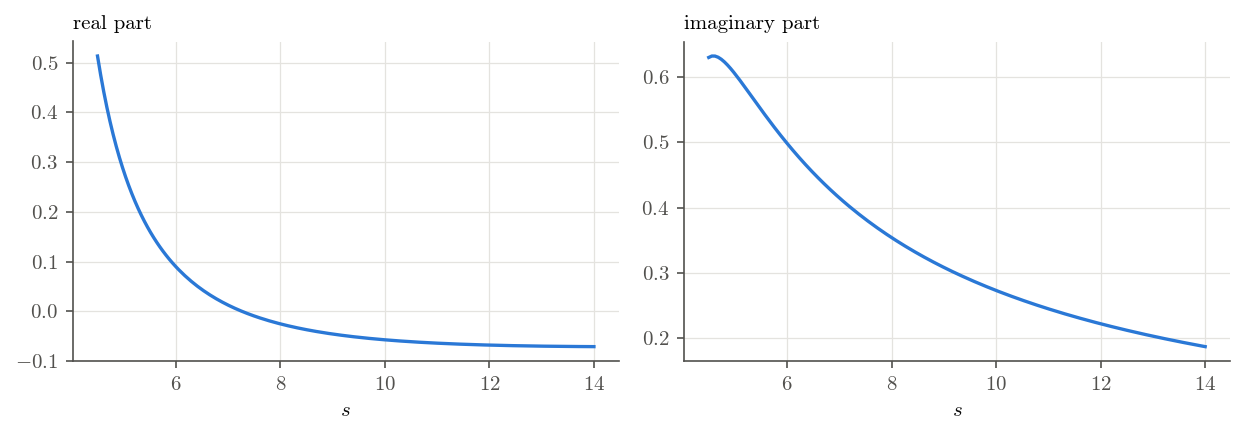

In [19]:
quick_plot(D0(1, 1, 1, 1, s, -2, 1, 1, 1, 1), (s, 4.5, 14));

## 7. QED at one loop: the electron's $g - 2$

The photon running across the electron vertex changes the magnetic moment of the electron. The vertex becomes
$\gamma^\mu F_1(q^2) + \frac{i\sigma^{\mu\nu}q_\nu}{2m}F_2(q^2)$ and $F_2(0) = (g - 2)/2$.

feynsage does the whole loop in one call:
- `projector('F2', 'mu', 'p1', 'm', 'p2', 'm')` picks out $F_2$: the incoming electron $p_1$ and the outgoing
  electron $p_2$, both of mass $m$, and the external photon index $\mu$
- `form_factor(line, projector, propagators..., kin=...)` does the trace with the projector and the loop
  integral. `line` lists the factors along the electron line: $\gamma^\rho$ (photon in the loop), the
  electron propagator numerator $\not p_2 - \not\ell + m$, $\gamma^\mu$, $\not p_1 - \not\ell + m$, $\gamma_\rho$
- the propagators: the photon `['l', '0']` (massless) and the two electrons `['l - p2', 'm']`, `['l - p1', 'm']`
- `kin`: both electrons on shell, $p_1\cdot p_2 = m^2 - q^2/2$ with $q = p_2 - p_1$

In [20]:
from feynsage.dirac import projector, form_factor
q2 = var('q2')
P = projector('F2', 'mu', 'p1', 'm', 'p2', 'm')
r = form_factor(['rho', 'p2 - l + m', 'mu', 'p1 - l + m', 'rho'], P,
                ['l', '0'], ['l - p2', 'm'], ['l - p1', 'm'],
                kin={'p1^2': 'm^2', 'p2^2': 'm^2', 'p1.p2': 'm^2 - q2/2'})
L = r.coefficients()['1']
print("1/eps pole of F2:", uv_part(L))
print("loop at q^2 = 0 :", finite_part(L, 1).subs(q2=0, m=1).n(digits=12).real())

1/eps pole of F2: 0
loop at q^2 = 0 : 2.00000000000


No $1/\epsilon$ pole: $F_2$ needs no renormalisation. With the prefactor $e^2/(16\pi^2) = \alpha/(4\pi)$ from the
vertices and the measure, $F_2(0) = \frac{\alpha}{4\pi}\times 2 = \frac{\alpha}{2\pi}$. This is Schwinger's result
of 1948, Peskin and Schroeder Section 6.3. `examples/peskin_examples.ipynb` does the same calculation step by
step, and also the vacuum polarisation.

## 8. Feynman parameters and the graph polynomials $\mathcal U$, $\mathcal F$

Feynman parameters $x_i$ (one per line) join all the propagators into one. Then the loop integral can be done
and only an integral over the $x_i$ is left. Everything about the diagram is then in two polynomials,
$\mathcal U$ and $\mathcal F$, and they can be read off the picture (spanning trees and 2-forests, see the tutorial).

A graph is written with `graph(lines, legs, kin)`:
- `lines`: `"A-B, B-C, C-A"` joins the vertices A, B, C (write `"A-B:m"` for a line of mass m)
- `legs`: the momentum that comes into each vertex from outside
- `kin`: the scalar products of those momenta

Here is a triangle with two massless legs and $Q^2 = (p_1 + p_2)^2$:

U = x1 + x2 + x3
F = (-Q2)*x1*x3


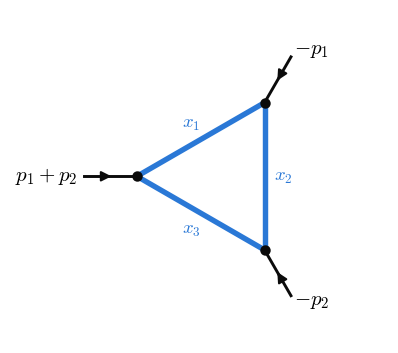

In [21]:
tri = graph("A-B, B-C, C-A", {"A": "p1 + p2", "B": "-p1", "C": "-p2"},
            kin={"p1^2": 0, "p2^2": 0, "p1.p2": "Q2/2"})
tri.plot();
print("U =", tri.U())
print("F =", tri.F())

$\mathcal U$ is the sum of the parameters. $\mathcal F$ has only the term that separates the vertex A (where
$Q$ comes in) from the rest. Ready-made diagrams are in `diagram()`, for example the massless box:

U = x1 + x2 + x3 + x4
F = (-s)*x1*x3 + (-t)*x2*x4


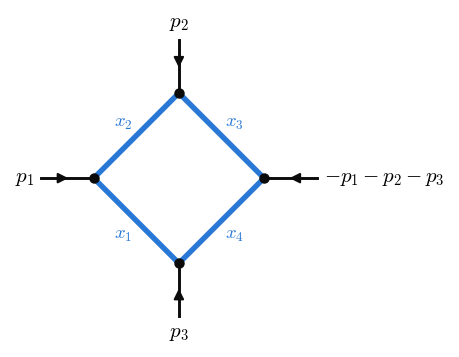

In [22]:
box = diagram("box")
box.plot();
print("U =", box.U())
print("F =", box.F())

**The Feynman parameter makes the loop a simple integral.** The finite part of the bubble is
$-\int_0^1 dx\,\log\big[(m^2 - x(1 - x)s)/\mu^2\big]$. Check it against `B0` at $s = 2$, $m = \mu = 1$ with Sage's
`numerical_integral`:

In [23]:
x = var('x')
print("Feynman parameter integral:", -numerical_integral(log(1 - x*(1 - x)*2), 0, 1)[0])
print("feynsage B0               :", finite_part(B0(2, 1, 1), 1).n().real())

Feynman parameter integral: 0.42920367320510344
feynsage B0               : 0.429203673205100


## 9. Two loops: many integrals, few master integrals

A loop calculation produces many integrals: the same propagators with different powers. Integration by parts
(IBP) gives linear relations between them, so all of them are combinations of a few **master integrals**.
`ibp_reduce` finds these combinations.

First the bubble with two massive lines. `family` writes down the propagators (a pair `("momentum", "mass")`
for a massive line) and the kinematics. The integral with the powers $a_1, a_2$ is called `J(a1,a2)`:
`J(2,1)` has the first propagator squared. The variable `d` is the dimension $D$.

In [24]:
bub = family([("l", "m"), ("l - p", "m")], kin={"p^2": "s"}, name="J")
red = ibp_reduce(bub, ["J(2,1)"])
print("masters:", red.masters)
red

masters: [(0, 1), (1, 1)]


J(2,1) = [(-1) * (d - 3) * (-4*m^2 + s)^-1] J(1,1) + [(1/2) * m^-2 * (d - 2) * (-4*m^2 + s)^-1] J(0,1)

Two masters: the bubble `J(1,1)` and the tadpole `J(0,1)`. `red.draw` shows the result as an equation of
diagrams. A pink dot means the line is squared and a line with power 0 is shrunk to a point:

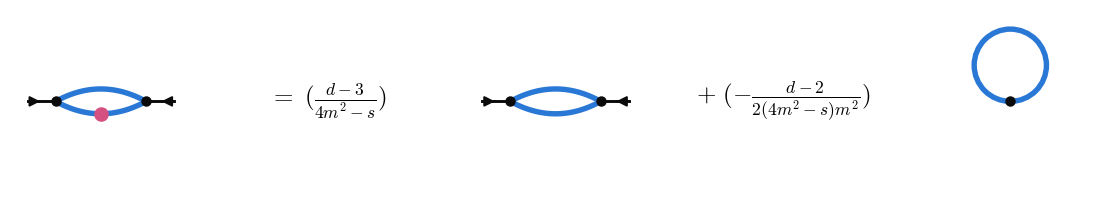

In [25]:
red.draw(diagram("bubble_mass"));

**A real two-loop example.** The massless two-loop kite has five lines. One call reduces it to two simpler
diagrams, each a product of Gamma functions:

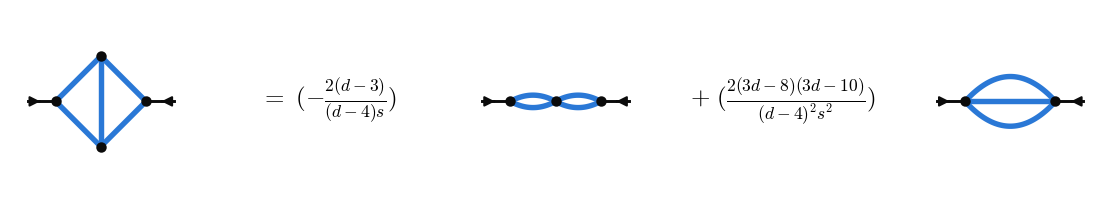

In [26]:
kite = family(["l1", "l1 + q", "l1 + l2", "l1 + l2 + q", "l2"], kin={"q^2": "s"}, name="F")
red2 = ibp_reduce(kite, ["F(1,1,1,1,1)"])
red2.draw(diagram("kite"));

The kite is a sum of the product of two bubbles and the sunset. The coefficients have $(d - 4)$ in the
denominator, but when everything is expanded around $d = 4$ the poles cancel. In Euclidean space, with the
measure $d^D\ell/\pi^{D/2}$ for each loop, what is left is the famous $6\zeta(3)/q^2$ of this diagram. The same reduction comes out of Kira 3.1, coefficient by coefficient.

## 10. Getting help inside feynsage

- `info(f)` prints what a function computes and what its output means
- many functions take `explain=True` and then say what they did
- `docs/REFERENCE.md` lists every function with its arguments

In [27]:
info(C0)

C0
--
Scalar triangle C0(s1, s12, s2; m0, m1, m2), propagators (l, m0), (l + p1, m1), (l + p2, m2),
s1 = p1^2, s2 = p2^2, s12 = (p1 - p2)^2 (Package-X order).
Output: IR finite -> the symbol C0(...) (.n() gives > 30 digits, explicit() the dilogarithms);
IR divergent (soft or collinear) -> c_-2/eps^2 + c_-1/eps + c_0 with mu, poles explicit.


In [28]:
PVB(0, 0, s, 1, 1, explain=True)

PV coefficient B_{00..(2r) 11..(n)}(s; m1, m2) as Package-X's PVB[r, n, s, m1, m2]:
PVB(0,0) = B0, PVB(0,1) = B1, PVB(1,0) = B00, PVB(0,2) = B11.  Exact, expanded to eps^0.


1/eps + DiscB(s, 1, 1) + log(mu^2) + 2

## 11. Your own calculation: a checklist and exercises

**Checklist**
1. Draw all diagrams at the order you want. Count the symmetry factors.
2. Write the amplitude with the Feynman rules of your theory (on paper).
3. Do the Dirac algebra with `spin_sum(M * conjugate(M))`, `dirac_trace` and `contract` (spin sums become traces).
4. Do the loops with `loop`, `B0`, `C0`, `D0` (one loop) or `family` and `ibp_reduce` (more loops).
5. Remember the normalisation: $\int\frac{d^4\ell}{(2\pi)^4} = \frac{i}{16\pi^2}\times$(feynsage's one-loop functions).
6. The $1/\epsilon$ poles must go away in a physical answer, through counterterms or because they cancel
   (the Ward identity of QED, or soft divergences against real emission). If they do not, look for a missing
   diagram or a factor.
7. Check every number in two ways: a known limit, a second method (`c0_numeric`, `d0_numeric`, a Feynman
   parameter integral) or a textbook formula.

**Common mistakes**
- Sage names cannot contain `^`, so momenta and kinematics are written as strings: `"p^2"`, `"l + p"`
- `A0` ... `D0` live in Minkowski space with $+i0$. Above a threshold they have an imaginary part, that is physics
- `family` and `ibp_reduce` name the dimension `d`. `loop`, `B0`, ... are already expanded in `eps`

**Exercises**
1. Put the muon mass back in Section 1: write `ubar(k, M)` and `v(kp, M)` in the amplitude and `dot(k, k): M^2`,
   `dot(kp, kp): M^2` in the rules (with a mass the other scalar products change too). Compare with Peskin and
   Schroeder eq. (5.12).
2. Take `B0(s, 1, 2)`. Where is the threshold now? Check that the imaginary part starts there.
3. Reduce `J(3,1)` and `J(2,2)` of the bubble family. Print each coefficient with `.factor()` to see where it has poles.
4. Make the massless triangle of Section 6 with `graph` and compare its $\mathcal F$ with the one of Section 8.
5. Look at `diagram()` for more ready-made diagrams and read off $\mathcal U$ and $\mathcal F$ of the sunset.

**Where next**
- `docs/tutorial/feynsage_tutorial.pdf`: the step-by-step tutorial following the lecture
- `examples/peskin_examples.ipynb`: vacuum polarisation and $g - 2$ in full
- `examples/feynsage_walkthrough.ipynb`: the whole package, also harder examples
- `examples/dirac_algebra.ipynb` and `docs/dirac_algebra.md`: more Dirac algebra (traces, $\gamma_5$, spin and polarization sums, colour)
- Prof. B. Ananthanarayan's lectures at IMSc, Chennai: [Introductory lectures on Feynman Integrals Part1](https://youtu.be/tvCBzU9GWeI)